# Risk of death — average Beirut resident, 8 April 2026

Estimates the probability that an **average Beirut resident** would have been killed during the Israeli strikes of **8 April 2026**.

Three complementary estimators, all reported in **micromorts** (1 µM = 1-in-1,000,000):

1. **Empirical base rate** — `deaths / population`
2. **Strike density + lethal footprint** — physics-based cross-check
3. **Back-solved effective lethality** — calibration check

**Data sources.** Lebanese Ministry of Public Health (authoritative nationwide totals, updated Apr 9) and Lebanese General Directorate of Civil Defense (preliminary Apr 8 district-level breakdown). Where the Health Ministry hasn't published a district split, we scale the Civil Defense district shares by the Health Ministry uplift ratio.

**Read the caveats at the bottom.** The 'average resident' figure hides huge neighborhood-level variance and is only meaningful as a coarse magnitude.

## Setup

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## Casualty data

**Health Ministry** (authoritative, Apr 9) reports nationwide totals of **300+ killed and ~1,600 wounded** — still rising.

**Civil Defense** (preliminary, Apr 8) published a district-level breakdown totaling 254 killed / 1,165 wounded. We use its *shares* to decompose the Health Ministry nationwide total into Beirut (92), Dahiyeh (61), and other districts, marked as `health_ministry_scaled`.

The Civil Defense district breakdown (Apr 8, preliminary):

| District | Killed | Wounded |
|---|---|---|
| Beirut (governorate) | 92 | 742 |
| Dahiyeh (southern suburbs) | 61 | 200 |
| Hermel | 9 | 6 |
| Baalbak | 18 | 28 |
| Aley | 17 | 6 |
| Saida | 12 | 56 |
| Nabatieh | 28 | 59 |
| Tyre | 17 | 68 |
| **Nationwide** | **254** | **1,165** |

In [2]:
# Health Ministry: authoritative nationwide total, updated Apr 9 (rising).
HM_NATIONWIDE_KILLED  = 300
HM_NATIONWIDE_WOUNDED = 1600

# Civil Defense: preliminary Apr 8 with district-level breakdown.
CD_NATIONWIDE_KILLED  = 254
CD_NATIONWIDE_WOUNDED = 1165

# Scaling: assume district shares are stable as the total rises.
uplift_killed  = HM_NATIONWIDE_KILLED  / CD_NATIONWIDE_KILLED
uplift_wounded = HM_NATIONWIDE_WOUNDED / CD_NATIONWIDE_WOUNDED

casualties = pd.DataFrame([
    # Nationwide
    {'source': 'civil_defense_prelim', 'scope': 'nationwide',     'killed': 254, 'wounded': 1165},
    {'source': 'health_ministry',      'scope': 'nationwide',     'killed': HM_NATIONWIDE_KILLED, 'wounded': HM_NATIONWIDE_WOUNDED},

    # Civil Defense district breakdown (preliminary, Apr 8)
    {'source': 'civil_defense_prelim', 'scope': 'beirut_gov',     'killed': 92,  'wounded': 742},
    {'source': 'civil_defense_prelim', 'scope': 'dahiyeh',        'killed': 61,  'wounded': 200},
    {'source': 'civil_defense_prelim', 'scope': 'greater_beirut', 'killed': 153, 'wounded': 942},

    # Scaled to Health Ministry nationwide (updated estimate, Apr 9)
    {'source': 'health_ministry_scaled', 'scope': 'beirut_gov',     'killed': round(92  * uplift_killed), 'wounded': round(742 * uplift_wounded)},
    {'source': 'health_ministry_scaled', 'scope': 'dahiyeh',        'killed': round(61  * uplift_killed), 'wounded': round(200 * uplift_wounded)},
    {'source': 'health_ministry_scaled', 'scope': 'greater_beirut', 'killed': round(153 * uplift_killed), 'wounded': round(942 * uplift_wounded)},
])
print(f'Health Ministry uplift : killed x{uplift_killed:.2f}, wounded x{uplift_wounded:.2f}')
casualties

Health Ministry uplift : killed x1.18, wounded x1.37


,source,scope,killed,wounded
0,civil_defense_prelim,nationwide,254,1165
1,health_ministry,nationwide,300,1600
2,civil_defense_prelim,beirut_gov,92,742
3,civil_defense_prelim,dahiyeh,61,200
4,civil_defense_prelim,greater_beirut,153,942
5,health_ministry_scaled,beirut_gov,109,1019
6,health_ministry_scaled,dahiyeh,72,275
7,health_ministry_scaled,greater_beirut,181,1294


In [3]:
# Strike counts — coarse figures from news reports.
# Nationwide: ~100 targets in ~10 minutes with ~50 jets and ~160 munitions.
strike_counts = {
    'nationwide_targets':   100,
    'nationwide_munitions': 160,
    'jets':                 50,
    # Beirut + Dahiyeh combined. Range to propagate uncertainty.
    'beirut_strikes_low':   10,
    'beirut_strikes_mid':   25,
    'beirut_strikes_high':  50,
}
strike_counts

{'nationwide_targets': 100,
 'nationwide_munitions': 160,
 'jets': 50,
 'beirut_strikes_low': 10,
 'beirut_strikes_mid': 25,
 'beirut_strikes_high': 50}

In [4]:
# Population denominators, matched to the casualty scopes.
populations = {
    'beirut_gov':       361_000,      # Beirut municipality / governorate
    'dahiyeh':          600_000,      # Southern suburbs (dense, urban)
    'greater_beirut': 2_200_000,      # Metropolitan area
    'nationwide':     5_300_000,      # Lebanon total
}

# Approximate urban areas (km²), used by Estimator B.
areas_km2 = {
    'beirut_gov':       20.0,
    'dahiyeh':          15.0,
    'greater_beirut':   85.0,
    'nationwide':     10452.0,
}
populations

{'beirut_gov': 361000,
 'dahiyeh': 600000,
 'greater_beirut': 2200000,
 'nationwide': 5300000}

## Parameters panel

In [5]:
params = {
    # Per-strike lethal area in km². Air-dropped bombs in dense urban terrain
    # have lethal radii ~15–50 m → A = pi * r^2 → 7e-4 to 8e-3 km².
    'a_lethal_km2_low':  math.pi * (15/1000)**2,
    'a_lethal_km2_mid':  math.pi * (30/1000)**2,
    'a_lethal_km2_high': math.pi * (50/1000)**2,
}
params

{'a_lethal_km2_low': 0.0007068583470577034,
 'a_lethal_km2_mid': 0.0028274333882308137,
 'a_lethal_km2_high': 0.007853981633974483}

## Estimator A — empirical base rate

`P(death) = deaths / population`, matched scope-to-scope (Beirut deaths ÷ Beirut population, etc.).

In [6]:
def estimator_a(casualties_df, populations):
    rows = []
    for _, c in casualties_df.iterrows():
        pop = populations.get(c['scope'])
        if pop is None:
            continue
        p = c['killed'] / pop
        rows.append({
            'source':     c['source'],
            'scope':      c['scope'],
            'deaths':     int(c['killed']),
            'population': pop,
            'p_death':    p,
            'micromorts': p * 1e6,
            'one_in_x':   (1 / p) if p > 0 else float('inf'),
        })
    return pd.DataFrame(rows).sort_values('micromorts').reset_index(drop=True)

est_a = estimator_a(casualties, populations)
est_a

,source,scope,deaths,population,p_death,micromorts,one_in_x
0,civil_defense_prelim,nationwide,254,5300000,0.0000,47.9245,"20,866.1417"
1,health_ministry,nationwide,300,5300000,0.0001,56.6038,"17,666.6667"
2,civil_defense_prelim,greater_beirut,153,2200000,0.0001,69.5455,"14,379.0850"
3,health_ministry_scaled,greater_beirut,181,2200000,0.0001,82.2727,"12,154.6961"
4,civil_defense_prelim,dahiyeh,61,600000,0.0001,101.6667,"9,836.0656"
5,health_ministry_scaled,dahiyeh,72,600000,0.0001,120.0000,"8,333.3333"
6,civil_defense_prelim,beirut_gov,92,361000,0.0003,254.8476,"3,923.9130"
7,health_ministry_scaled,beirut_gov,109,361000,0.0003,301.9391,"3,311.9266"


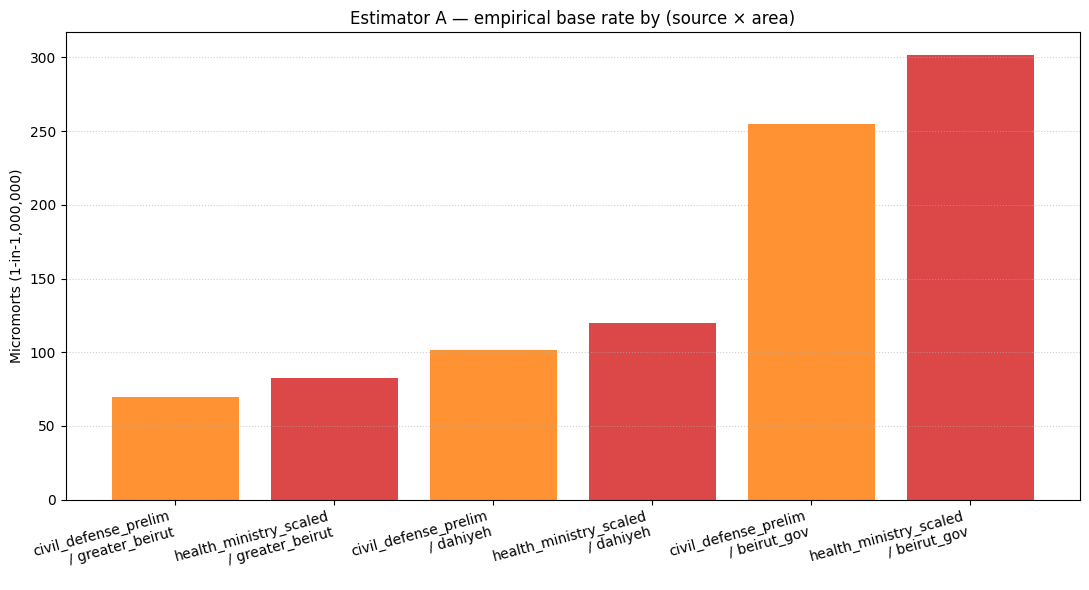

Beirut range :    69.5 – 301.9 µM
Median       :   110.8 µM

Best single answer for average Beirut resident = health_ministry_scaled × greater_beirut:
  82.3 µM   (≈ 1 in 12,155)


In [7]:
# Focus chart on Beirut-relevant rows (not nationwide).
beirut_rows = est_a[est_a['scope'].isin(['beirut_gov', 'dahiyeh', 'greater_beirut'])].copy()
beirut_rows = beirut_rows.sort_values('micromorts')

fig, ax = plt.subplots(figsize=(11, 6))
labels = [f"{r.source}\n/ {r.scope}" for r in beirut_rows.itertuples()]
colors = ['tab:red' if 'health_ministry' in r.source else 'tab:orange' for r in beirut_rows.itertuples()]
ax.bar(labels, beirut_rows['micromorts'], color=colors, alpha=0.85)
ax.set_ylabel('Micromorts (1-in-1,000,000)')
ax.set_title('Estimator A — empirical base rate by (source × area)')
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f"Beirut range : {beirut_rows['micromorts'].min():7.1f} – {beirut_rows['micromorts'].max():.1f} µM")
print(f"Median       : {beirut_rows['micromorts'].median():7.1f} µM")
print()
print('Best single answer for average Beirut resident = health_ministry_scaled × greater_beirut:')
central_row = est_a.query("source=='health_ministry_scaled' and scope=='greater_beirut'").iloc[0]
print(f"  {central_row['micromorts']:.1f} µM   (≈ 1 in {1e6/central_row['micromorts']:,.0f})")

## Estimator B — strike density + lethal footprint

Naive physics model: each strike produces a lethal zone of area `A_lethal`; assume uniform exposure.

```
P(death) ≈ 1 − (1 − A_lethal / A_city) ** N_strikes
```

This is a rough upper bound that ignores shelter and targeting.

In [8]:
def estimator_b(n_strikes, a_lethal_km2, a_city_km2):
    p_miss_single = 1 - a_lethal_km2 / a_city_km2
    return 1 - p_miss_single ** n_strikes

rows = []
for n_label, n in [
    ('low',  strike_counts['beirut_strikes_low']),
    ('mid',  strike_counts['beirut_strikes_mid']),
    ('high', strike_counts['beirut_strikes_high']),
]:
    for a_label, a in [
        ('small_munition', params['a_lethal_km2_low']),
        ('typical',       params['a_lethal_km2_mid']),
        ('large_munition', params['a_lethal_km2_high']),
    ]:
        for scope_name in ['beirut_gov', 'greater_beirut']:
            area = areas_km2[scope_name]
            p = estimator_b(n, a, area)
            rows.append({
                'n_strikes':  f'{n_label}({n})',
                'a_lethal':   a_label,
                'scope':      scope_name,
                'p_death':    p,
                'micromorts': p * 1e6,
            })

est_b = pd.DataFrame(rows)
print(f"Range : {est_b['micromorts'].min():7.2f} – {est_b['micromorts'].max():.2f} µM")
print(f"Median: {est_b['micromorts'].median():7.2f} µM")
est_b.sort_values('micromorts').head(10)

Range :   83.16 – 19447.23 µM
Median: 1537.33 µM


,n_strikes,a_lethal,scope,p_death,micromorts
1,low(10),small_munition,greater_beirut,0.0001,83.1567
7,mid(25),small_munition,greater_beirut,0.0002,207.8788
3,low(10),typical,greater_beirut,0.0003,332.5894
0,low(10),small_munition,beirut_gov,0.0004,353.3730
13,high(50),small_munition,greater_beirut,0.0004,415.7143
9,mid(25),typical,greater_beirut,0.0008,831.2662
6,mid(25),small_munition,beirut_gov,0.0009,883.1983
5,low(10),large_munition,greater_beirut,0.0009,923.6137
2,low(10),typical,beirut_gov,0.0014,"1,412.8177"
15,high(50),typical,greater_beirut,0.0017,"1,661.8414"


## Estimator C — back-solved effective lethality

Invert Estimator B: given observed deaths, what *effective* lethal radius per strike would be needed?

In [9]:
def back_solve_a_lethal(deaths, population, area_km2, n_strikes):
    # p = n * a_lethal / area => a_lethal = (deaths/pop) * area / n
    return (deaths / population) * area_km2 / n_strikes

beirut_scopes = ['beirut_gov', 'dahiyeh', 'greater_beirut']
scenarios = []
for _, c in casualties[casualties['scope'].isin(beirut_scopes)].iterrows():
    pop  = populations[c['scope']]
    area = areas_km2[c['scope']]
    for n_label, n in [
        ('low',  strike_counts['beirut_strikes_low']),
        ('mid',  strike_counts['beirut_strikes_mid']),
        ('high', strike_counts['beirut_strikes_high']),
    ]:
        a_eff   = back_solve_a_lethal(c['killed'], pop, area, n)
        r_eff_m = math.sqrt(a_eff / math.pi) * 1000
        scenarios.append({
            'source':    c['source'],
            'scope':     c['scope'],
            'n_strikes': n,
            'a_lethal_eff_km2': a_eff,
            'radius_eff_m':     r_eff_m,
        })

est_c = pd.DataFrame(scenarios)
print('Back-solved effective lethal radius (m) per strike:')
print(f"  range : {est_c['radius_eff_m'].min():.0f} – {est_c['radius_eff_m'].max():.0f} m")
print(f"  median: {est_c['radius_eff_m'].median():.0f} m")
print()
print('Compare to published single-bomb lethal radii (~15–50 m).')
print('Smaller back-solved radii mean strikes hit specific buildings rather')
print('than random ground, so the naive Estimator B overestimates.')
est_c.head(10)

Back-solved effective lethal radius (m) per strike:
  range : 3 – 15 m
  median: 7 m

Compare to published single-bomb lethal radii (~15–50 m).
Smaller back-solved radii mean strikes hit specific buildings rather
than random ground, so the naive Estimator B overestimates.


,source,scope,n_strikes,a_lethal_eff_km2,radius_eff_m
0,civil_defense_prelim,beirut_gov,10,0.0005,12.7374
1,civil_defense_prelim,beirut_gov,25,0.0002,8.0558
2,civil_defense_prelim,beirut_gov,50,0.0001,5.6963
3,civil_defense_prelim,dahiyeh,10,0.0002,6.9672
4,civil_defense_prelim,dahiyeh,25,0.0001,4.4065
5,civil_defense_prelim,dahiyeh,50,0.0000,3.1158
6,civil_defense_prelim,greater_beirut,10,0.0006,13.7173
7,civil_defense_prelim,greater_beirut,25,0.0002,8.6756
8,civil_defense_prelim,greater_beirut,50,0.0001,6.1346
9,health_ministry_scaled,beirut_gov,10,0.0006,13.8644


## Comparison baselines

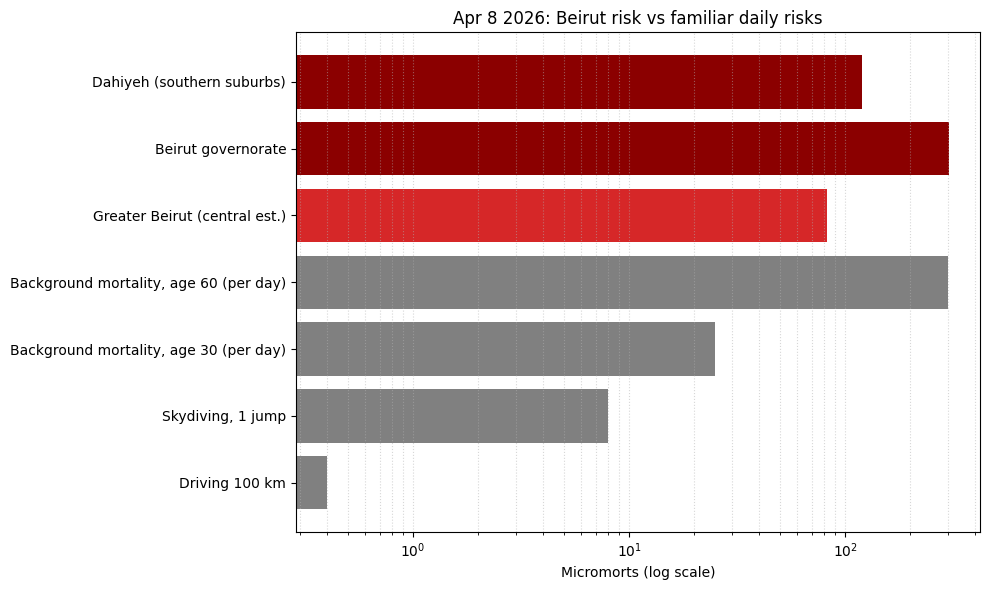

Greater Beirut central :    82.3 µM   (≈ 1 in 12,155)
Beirut governorate     :   301.9 µM   (≈ 1 in 3,312)
Dahiyeh                :   120.0 µM   (≈ 1 in 8,333)

Vs ~25 µM normal day for age 30:
  greater_beirut :   3.3x normal day
  beirut_gov     :  12.1x normal day
  dahiyeh        :   4.8x normal day


In [10]:
baselines = {
    'Driving 100 km':                            0.4,
    'Skydiving, 1 jump':                         8.0,
    'Background mortality, age 30 (per day)':   25.0,
    'Background mortality, age 60 (per day)':  300.0,
}

central     = est_a.query("source=='health_ministry_scaled' and scope=='greater_beirut'").iloc[0]
central_uM  = central['micromorts']
beirut_gov  = est_a.query("source=='health_ministry_scaled' and scope=='beirut_gov'").iloc[0]
dahiyeh     = est_a.query("source=='health_ministry_scaled' and scope=='dahiyeh'").iloc[0]

data = dict(baselines)
data['Greater Beirut (central est.)'] = central_uM
data['Beirut governorate']            = beirut_gov['micromorts']
data['Dahiyeh (southern suburbs)']    = dahiyeh['micromorts']

fig, ax = plt.subplots(figsize=(10, 6))
labels = list(data.keys())
values = list(data.values())
colors = ['gray'] * len(baselines) + ['tab:red', 'darkred', '#8b0000']
ax.barh(labels, values, color=colors)
ax.set_xscale('log')
ax.set_xlabel('Micromorts (log scale)')
ax.set_title('Apr 8 2026: Beirut risk vs familiar daily risks')
ax.grid(axis='x', which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Greater Beirut central : {central_uM:7.1f} µM   (≈ 1 in {1e6/central_uM:,.0f})")
print(f"Beirut governorate     : {beirut_gov['micromorts']:7.1f} µM   (≈ 1 in {1e6/beirut_gov['micromorts']:,.0f})")
print(f"Dahiyeh                : {dahiyeh['micromorts']:7.1f} µM   (≈ 1 in {1e6/dahiyeh['micromorts']:,.0f})")
print()
print('Vs ~25 µM normal day for age 30:')
print(f"  greater_beirut : {central_uM/25:5.1f}x normal day")
print(f"  beirut_gov     : {beirut_gov['micromorts']/25:5.1f}x normal day")
print(f"  dahiyeh        : {dahiyeh['micromorts']/25:5.1f}x normal day")

## Sensitivity — which assumption swings the number most?

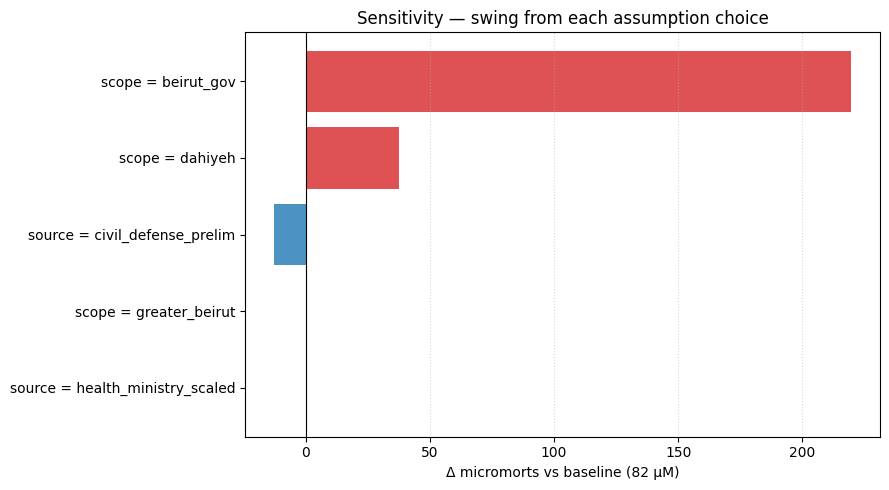

,variation,micromorts,delta
1,source = health_ministry_scaled,82.2727,0.0000
4,scope = greater_beirut,82.2727,0.0000
0,source = civil_defense_prelim,69.5455,-12.7273
3,scope = dahiyeh,120.0000,37.7273
2,scope = beirut_gov,301.9391,219.6663


In [11]:
baseline = est_a.query("source=='health_ministry_scaled' and scope=='greater_beirut'").iloc[0]['micromorts']

variations = []
# Vary source, fix scope = greater_beirut
for src in ['civil_defense_prelim', 'health_ministry_scaled']:
    sub = est_a.query(f"source=='{src}' and scope=='greater_beirut'")
    if len(sub):
        variations.append((f'source = {src}', sub.iloc[0]['micromorts']))
# Vary scope, fix source = health_ministry_scaled
for scope in ['beirut_gov', 'dahiyeh', 'greater_beirut']:
    sub = est_a.query(f"source=='health_ministry_scaled' and scope=='{scope}'")
    if len(sub):
        variations.append((f'scope = {scope}', sub.iloc[0]['micromorts']))

df_var = pd.DataFrame(variations, columns=['variation', 'micromorts'])
df_var['delta'] = df_var['micromorts'] - baseline
df_var = df_var.reindex(df_var['delta'].abs().sort_values().index)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tab:red' if d > 0 else 'tab:blue' for d in df_var['delta']]
ax.barh(df_var['variation'], df_var['delta'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Δ micromorts vs baseline ({baseline:.0f} µM)')
ax.set_title('Sensitivity — swing from each assumption choice')
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

df_var

## Summary

In [12]:
beirut_mask = est_a['scope'].isin(['beirut_gov', 'dahiyeh', 'greater_beirut'])
a_range    = (est_a[beirut_mask]['micromorts'].min(), est_a[beirut_mask]['micromorts'].max())
a_central  = est_a.query("source=='health_ministry_scaled' and scope=='greater_beirut'").iloc[0]['micromorts']
a_gov      = est_a.query("source=='health_ministry_scaled' and scope=='beirut_gov'").iloc[0]['micromorts']
a_dahiyeh  = est_a.query("source=='health_ministry_scaled' and scope=='dahiyeh'").iloc[0]['micromorts']

print('=' * 72)
print(' SUMMARY — Apr 8 2026 Israeli strikes on Lebanon')
print(' Risk of death for an average Beirut resident that day')
print('=' * 72)
print()
print(f' Estimator A (empirical), Beirut rows : {a_range[0]:6.1f} – {a_range[1]:.1f} µM')
print()
print(f' Health Ministry scaled — by area:')
print(f'   Greater Beirut      : {a_central:6.1f} µM  (≈ 1 in {1e6/a_central:,.0f})  — central estimate')
print(f'   Beirut governorate  : {a_gov:6.1f} µM  (≈ 1 in {1e6/a_gov:,.0f})')
print(f'   Dahiyeh             : {a_dahiyeh:6.1f} µM  (≈ 1 in {1e6/a_dahiyeh:,.0f})')
print()
print(f' Context — ~25 µM is a normal-day background mortality for a healthy 30-year-old.')
print(f' On Apr 8 the daily risk of death for an average Beirut resident was roughly:')
print(f'   Greater Beirut      : {a_central/25:5.1f}x a normal day')
print(f'   Beirut governorate  : {a_gov/25:5.1f}x a normal day')
print(f'   Dahiyeh             : {a_dahiyeh/25:5.1f}x a normal day')
print()
print(' *** These are averages over large populations. Residents of directly-hit')
print(' *** blocks faced risks orders of magnitude higher.')
print(' *** Health Ministry says totals are preliminary and expected to rise.')

 SUMMARY — Apr 8 2026 Israeli strikes on Lebanon
 Risk of death for an average Beirut resident that day

 Estimator A (empirical), Beirut rows :   69.5 – 301.9 µM

 Health Ministry scaled — by area:
   Greater Beirut      :   82.3 µM  (≈ 1 in 12,155)  — central estimate
   Beirut governorate  :  301.9 µM  (≈ 1 in 3,312)
   Dahiyeh             :  120.0 µM  (≈ 1 in 8,333)

 Context — ~25 µM is a normal-day background mortality for a healthy 30-year-old.
 On Apr 8 the daily risk of death for an average Beirut resident was roughly:
   Greater Beirut      :   3.3x a normal day
   Beirut governorate  :  12.1x a normal day
   Dahiyeh             :   4.8x a normal day

 *** These are averages over large populations. Residents of directly-hit
 *** blocks faced risks orders of magnitude higher.
 *** Health Ministry says totals are preliminary and expected to rise.


## Caveats

1. **Totals still rising.** The Lebanese Ministry of Public Health (authoritative source) says the 300+ figure is preliminary. Rescue teams are still pulling bodies from rubble. Any number here is a lower bound.
2. **Non-uniform targeting.** Strikes cluster in specific neighborhoods. The citywide average hides orders-of-magnitude variance between blocks.
3. **Non-uniform exposure.** People shelter, flee, or crowd. The uniform-distribution assumption in Estimator B is wrong; Estimator C quantifies that gap.
4. **District shares assumed stable.** The `health_ministry_scaled` rows apply the Civil Defense preliminary per-district *share* to the Health Ministry nationwide total. If the Health Ministry later publishes a district breakdown that differs, these rows should be replaced with direct figures.
5. **Direct blast only.** Ignores hospital-overload deaths, loss of services, displacement, longer-term health effects, and psychological harm.
6. **One-day window.** Single-day estimates are high-variance — this is the risk for *this specific day*, not a war-average.

## Live data fetchers (optional)

In [13]:
# ReliefWeb (OCHA) — no API key needed.
import requests

try:
    r = requests.get(
        'https://api.reliefweb.int/v1/reports',
        params={
            'appname':      'estimate-proj-leb',
            'query[value]': 'Lebanon airstrikes April 2026',
            'limit':        5,
            'sort[]':       'date:desc',
            'profile':      'list',
        },
        timeout=10,
    )
    r.raise_for_status()
    data = r.json()
    items = data.get('data', [])
    if not items:
        print('ReliefWeb returned 0 matching reports.')
    for item in items:
        f = item.get('fields', {})
        title = f.get('title', '')
        date  = (f.get('date') or {}).get('created', '')[:10]
        print(f'  {date}  {title}')
except Exception as e:
    print(f'ReliefWeb fetch failed (non-fatal): {e}')

/Users/sherif.maktabi/Documents/Personal Projects/estimate-proj-leb/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


ReliefWeb fetch failed (non-fatal): 410 Client Error: Gone for url: https://api.reliefweb.int/v1/reports?appname=estimate-proj-leb&query%5Bvalue%5D=Lebanon+airstrikes+April+2026&limit=5&sort%5B%5D=date%3Adesc&profile=list


In [14]:
# ACLED — requires free API key. Register at https://acleddata.com/register/
import os

ACLED_KEY   = os.environ.get('ACLED_KEY')
ACLED_EMAIL = os.environ.get('ACLED_EMAIL')

if not (ACLED_KEY and ACLED_EMAIL):
    print('Skipping ACLED fetch — set ACLED_KEY and ACLED_EMAIL env vars.')
else:
    try:
        r = requests.get(
            'https://api.acleddata.com/acled/read',
            params={
                'key':        ACLED_KEY,
                'email':      ACLED_EMAIL,
                'country':    'Lebanon',
                'event_date': '2026-04-08',
                'limit':      200,
            },
            timeout=15,
        )
        r.raise_for_status()
        payload = r.json()
        events  = payload.get('data', [])
        print(f'ACLED events for Lebanon 2026-04-08: {len(events)}')
        if events:
            acled_df = pd.DataFrame(events)
            cols = [c for c in ['event_date', 'event_type', 'location', 'fatalities', 'notes'] if c in acled_df.columns]
            display(acled_df[cols].head(20))
    except Exception as e:
        print(f'ACLED fetch failed (non-fatal): {e}')

Skipping ACLED fetch — set ACLED_KEY and ACLED_EMAIL env vars.


## Sanity checks

In [15]:
assert (casualties['killed']  >= 0).all()
assert (casualties['wounded'] >= 0).all()

nationwide = casualties[casualties['scope'] == 'nationwide'].set_index('source')['killed']
beirut_gb  = casualties[casualties['scope'] == 'greater_beirut'].set_index('source')['killed']
assert beirut_gb['civil_defense_prelim']    <= nationwide['civil_defense_prelim']
assert beirut_gb['health_ministry_scaled'] <= nationwide['health_ministry']
print('✓ Greater Beirut deaths ≤ nationwide deaths (same source)')

assert (est_a['p_death'] >= 0).all() and (est_a['p_death'] <= 1).all()
assert (est_b['p_death'] >= 0).all() and (est_b['p_death'] <= 1).all()
print('✓ All probabilities in [0, 1]')

print('✓ All sanity checks passed.')

✓ Greater Beirut deaths ≤ nationwide deaths (same source)
✓ All probabilities in [0, 1]
✓ All sanity checks passed.
